<a href="https://colab.research.google.com/github/Tetbet/AQI_Predictor_BYOP/blob/main/notebooks/01_AQI_EDA_and_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Read the dataset directly from your public GitHub repository!
# This ensures anyone evaluating your project can run the code instantly.

url = 'https://raw.githubusercontent.com/Tetbet/AQI_Predictor_BYOP/main/city_day.csv'

# Load the data
df = pd.read_csv(url)

# Convert the 'Date' column to actual Datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Show the first 5 rows
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [5]:
print("Missing values in each column:\n")
print(df.isnull().sum())
print(f"\nTotal rows in dataset: {len(df)}")

Missing values in each column:

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Total rows in dataset: 29531


In [6]:
# Since this is time-series data, if today's sensor reading is missing,
# it's best to assume it's similar to yesterday's reading.
# We use 'ffill' (forward fill) grouped by each City.

# 1. Sort by City and Date to ensure chronological order
df = df.sort_values(['City', 'Date'])

# 2. Forward fill the missing values city by city
cols_to_fill = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI']

for col in cols_to_fill:
    df[col] = df.groupby('City')[col].ffill()
    # If the very first day is missing, ffill won't work, so we backward fill (bfill) as a backup
    df[col] = df.groupby('City')[col].bfill()

# 3. Drop any rows that STILL have no AQI (if a city had no AQI sensors at all)
df = df.dropna(subset=['AQI'])

print("Missing values after cleaning:\n")
print(df.isnull().sum())

Missing values after cleaning:

City              0
Date              0
PM2.5             0
PM10           2009
NO                0
NO2               0
NOx            1169
NH3            2009
CO                0
SO2               0
O3              162
Benzene        2732
Toluene        4010
Xylene        13047
AQI               0
AQI_Bucket     4681
dtype: int64


/tmp/ipykernel_4875/3150313626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AQI_Bucket', palette='viridis', order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe'])


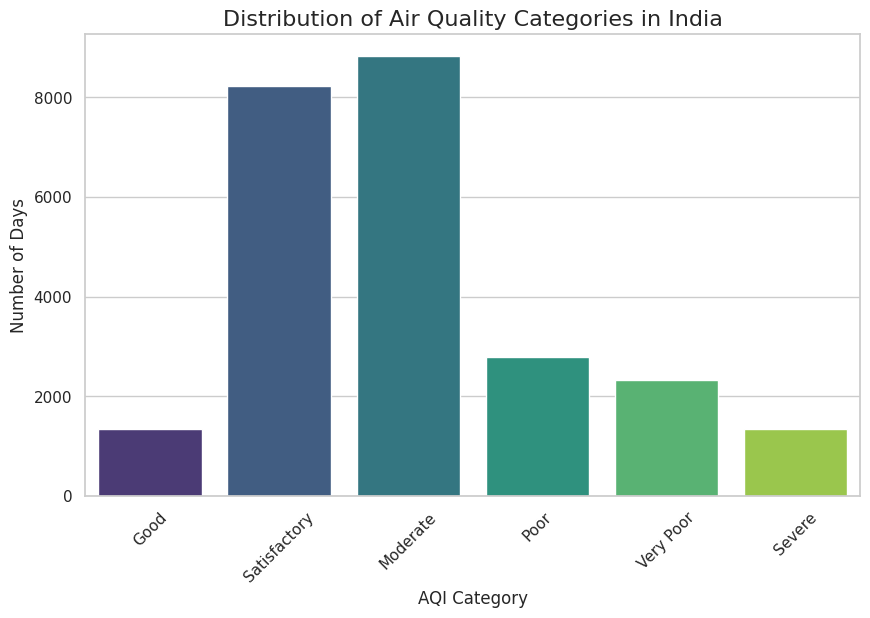

In [7]:
# GRAPH 1: Distribution of AQI Categories (For Classification)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='AQI_Bucket', palette='viridis', order=['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe'])
plt.title('Distribution of Air Quality Categories in India', fontsize=16)
plt.xlabel('AQI Category', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.xticks(rotation=45)
plt.show()

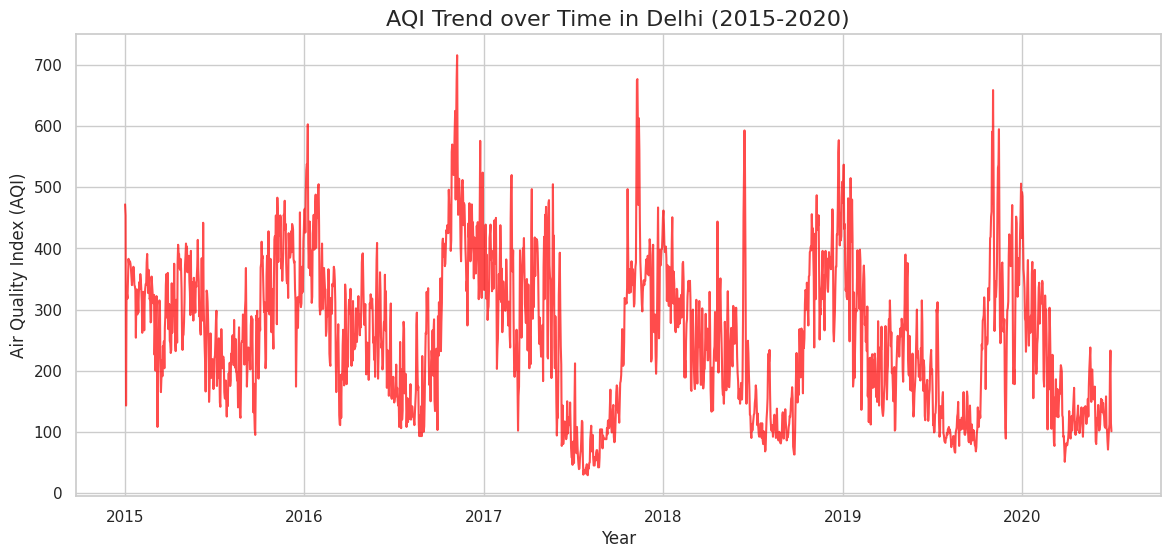

In [8]:
# GRAPH 2: AQI Trend over time for a specific city (Delhi) - (For Forecasting context)
delhi_data = df[df['City'] == 'Delhi'].copy()

plt.figure(figsize=(14, 6))
plt.plot(delhi_data['Date'], delhi_data['AQI'], color='red', alpha=0.7)
plt.title('AQI Trend over Time in Delhi (2015-2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Air Quality Index (AQI)', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
# GRAPH 3: Correlation Heatmap (To see which pollutants affect AQI the most)
# This is crucial for the Machine Learning Regression step!

# Select only the numerical columns for correlation
numeric_cols = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3', 'AQI']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Pollutants and AQI', fontsize=16)
plt.show()